In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

TOP50K_PATH = "top_50k_songs.csv"
MUSIC_INFO_PATH = "/project/pi_dagarwal_umass_edu/project_7/hmagapu/top_50k_full_augmented.csv"

In [2]:
top50k = pd.read_csv(TOP50K_PATH)
music = pd.read_csv(MUSIC_INFO_PATH)

print("Top 50K rows:", len(top50k))
print("Music Info rows:", len(music))

Top 50K rows: 50000
Music Info rows: 50000


In [3]:
import pandas as pd
from IPython.display import display

LASTFM_PATH = "/work/pi_dagarwal_umass_edu/project_7/hmagapu/metadata/shared/user_sessions_lastfm1k_minuser1000_minitem7_sessgap1200_minsesslen10_minhist50.csv"

lastfm = pd.read_csv(LASTFM_PATH)
print("LastFM rows:", len(lastfm))
print("Columns:", list(lastfm.columns))

LastFM rows: 4213959
Columns: ['user_000001', '2006-08-13T14:55:14.000000', '27613b78-1b9d-4ec3-9db5-fa0743465fdd', 'Herbie Hancock', '8e81302a-6cde-4818-8703-43b5356ce0a0', 'The Essence', '2']


In [ ]:
lastfm = pd.read_csv(
    LASTFM_PATH,
    header=None,
    names=[
        "user_id",
        "timestamp",
        "artist_mbid",
        "artist_name",
        "track_mbid",
        "track_name",
        "session_id"
    ]
)

print("LastFM rows:", len(lastfm))
lastfm.head()

LastFM rows: 4213960


,user_id,timestamp,artist_mbid,artist_name,track_mbid,track_name,session_id
0,user_000001,2006-08-13T14:55:14.000000,27613b78-1b9d-4ec3-9db5-fa0743465fdd,Herbie Hancock,8e81302a-6cde-4818-8703-43b5356ce0a0,The Essence,2
1,user_000001,2006-08-13T14:59:59.000000,a74b1b7f-71a5-4011-9441-d0b5e4122711,Radiohead,1c0377bb-c00b-4bbe-b4b2-615f13324adc,Idioteque,2
2,user_000001,2006-08-13T15:05:20.000000,477d1c52-3100-4493-a049-473d8f183e23,高木正勝,8f916d23-0510-4ad5-9a7f-8a076c3f14ca,Change Of Seasons,2
3,user_000001,2006-08-13T15:23:08.000000,f22942a1-6f70-4f48-866e-238cb2308fbd,Aphex Twin,6cb57d5e-da03-4bcd-b7b5-b08023890b42,Omgyjya Switch7,2
4,user_000001,2006-08-13T15:28:44.000000,f22942a1-6f70-4f48-866e-238cb2308fbd,Aphex Twin,8349030c-a3ab-4ced-9064-842aa894eacf,Fenix Funk 5,2


In [6]:
# LastFM benchmark statistics table

num_users = lastfm["user_id"].nunique()
total_scrobbles = len(lastfm)
unique_tracks = lastfm["track_name"].nunique()
unique_artists = lastfm["artist_name"].nunique()
num_sessions = lastfm["session_id"].nunique()

session_lengths = lastfm.groupby("session_id").size()
mean_session_length = session_lengths.mean()
median_session_length = session_lengths.median()

sparsity = total_scrobbles / (num_users * unique_tracks)

timestamps = pd.to_datetime(lastfm["timestamp"], errors="coerce")
date_min = timestamps.min().date()
date_max = timestamps.max().date()

lastfm_stats = pd.DataFrame({
    "Metric": [
        "Number of users",
        "Total scrobbles (rows)",
        "Unique tracks",
        "Unique artists",
        "Number of sessions",
        "Mean session length",
        "Median session length",
        "Sparsity (interactions / users x items)",
        "Date range of dataset"
    ],
    "Value": [
        num_users,
        total_scrobbles,
        unique_tracks,
        unique_artists,
        num_sessions,
        round(mean_session_length, 2),
        round(median_session_length, 2),
        round(sparsity, 6),
        f"{date_min} to {date_max}"
    ]
})

lastfm_stats

,Metric,Value
0,Number of users,814
1,Total scrobbles (rows),4213960
2,Unique tracks,295959
3,Unique artists,43406
4,Number of sessions,7073
5,Mean session length,595.78
6,Median session length,130.0
7,Sparsity (interactions / users x items),0.017492
8,Date range of dataset,2005-02-14 to 2009-06-19


In [10]:
if "df" not in globals():
    music_artist_col = "artist" if "artist" in music.columns else "artist_name"
    music_track_col = "name" if "name" in music.columns else "track_name"

    top50k["_artist"] = top50k["artist_name"].astype(str).str.lower().str.strip()
    top50k["_track"] = top50k["track_name"].astype(str).str.lower().str.strip()
    music["_artist"] = music[music_artist_col].astype(str).str.lower().str.strip()
    music["_track"] = music[music_track_col].astype(str).str.lower().str.strip()

    music_cols = [
        "_artist", "_track",
        "track_id", "spotify_id", "tags", "genre", "year",
        "duration_ms", "danceability", "energy", "key", "loudness", "mode",
        "speechiness", "acousticness", "instrumentalness", "liveness",
        "valence", "tempo", "time_signature",
    ]
    music_subset = music[music_cols].drop_duplicates(subset=["_artist", "_track"])
    df = top50k.merge(music_subset, on=["_artist", "_track"], how="left")

matched = df["spotify_id"].notna().sum()
coverage = matched / len(df) * 100

df["duration_min"] = df["duration_ms"] / 60000

num_genres = df["genre"].dropna().nunique()
top_genre = df["genre"].value_counts(dropna=True).idxmax()

year_min = int(df["year"].dropna().min())
year_max = int(df["year"].dropna().max())

top50k_stats = pd.DataFrame({
    "Metric": [
        "Total songs",
        "Unique artists",
        "Unique tracks",
        "Songs matched with metadata",
        "Coverage %",
        "Number of genres",
        "Top genre",
        "Average duration (min)",
        "Median duration (min)",
        "Release year range"
    ],
    "Value": [
        len(df),
        df["artist_name"].nunique(),
        df["track_name"].nunique(),
        matched,
        round(coverage, 2),
        num_genres,
        top_genre,
        round(df["duration_min"].mean(), 2),
        round(df["duration_min"].median(), 2),
        f"{year_min} to {year_max}"
    ]
})

top50k_stats

,Metric,Value
0,Total songs,50000
1,Unique artists,5751
2,Unique tracks,43503
3,Songs matched with metadata,47247
4,Coverage %,94.49
5,Number of genres,15
6,Top genre,Rock
7,Average duration (min),4.14
8,Median duration (min),3.92
9,Release year range,1900 to 2022


In [11]:
music_artist_col = "artist" if "artist" in music.columns else "artist_name"
music_track_col = "name" if "name" in music.columns else "track_name"

top50k["_artist"] = top50k["artist_name"].astype(str).str.lower().str.strip()
top50k["_track"] = top50k["track_name"].astype(str).str.lower().str.strip()

music["_artist"] = music[music_artist_col].astype(str).str.lower().str.strip()
music["_track"] = music[music_track_col].astype(str).str.lower().str.strip()

In [12]:
music_cols = [
    "_artist", "_track",
    "track_id", "spotify_id", "tags", "genre", "year",
    "duration_ms", "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "time_signature"
]

music_subset = music[music_cols].drop_duplicates(subset=["_artist", "_track"])
df = top50k.merge(music_subset, on=["_artist", "_track"], how="left")

print("Merged rows:", len(df))
df.head()

Merged rows: 50000


,track_index,artist_name,track_name,play_count,_artist,_track,track_id,spotify_id,tags,genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,0,The Postal Service,Such Great Heights,1016,the postal service,such great heights,TRCRCBT128F4260DD1,0cs7BfenkAuxTVJv96KMme,"rock, electronic, alternative, indie, pop, ind...",NaN,...,5.0,-8.447,1.0,0.0469,0.00918,0.230000,0.0672,0.199,174.979,4.0
1,1,Boy Division,Love Will Tear Us Apart,896,boy division,love will tear us apart,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Death Cab For Cutie,Soul Meets Body,884,death cab for cutie,soul meets body,NaN,5yc59J3MR3tVDPTOgwgRI5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Muse,Supermassive Black Hole,862,muse,supermassive black hole,TRRPNNQ12903CB411A,0v6Mi3f552jMW6dhYoKAbC,"rock, alternative, indie, alternative_rock, in...",NaN,...,7.0,-5.126,1.0,0.0445,0.03970,0.007150,0.2840,0.837,120.010,4.0
4,4,Radiohead,Karma Police,852,radiohead,karma police,TRXOGZT128F424AD74,01puceOqImrzSfKDAcd1Ia,"rock, alternative, indie, alternative_rock, in...",NaN,...,7.0,-9.129,1.0,0.0260,0.06260,0.000092,0.1720,0.317,74.807,4.0


In [13]:
matched = df["spotify_id"].notna().sum()
unmatched = df["spotify_id"].isna().sum()
coverage = round((matched / len(df)) * 100, 2)

summary_df = pd.DataFrame({
    "Metric": [
        "Total Songs",
        "Matched Songs",
        "Unmatched Songs",
        "Coverage %",
        "Unique Artists",
        "Unique Tracks"
    ],
    "Value": [
        len(df),
        matched,
        unmatched,
        coverage,
        df["artist_name"].nunique(),
        df["track_name"].nunique()
    ]
})

display(summary_df)

,Metric,Value
0,Total Songs,50000.00
1,Matched Songs,47247.00
2,Unmatched Songs,2753.00
3,Coverage %,94.49
4,Unique Artists,5751.00
5,Unique Tracks,43503.00


In [14]:
num_cols = [
    "year", "duration_ms", "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo"
]

num_stats = df[num_cols].describe()
display(num_stats)

,year,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,17944.000000,3.443300e+04,47088.000000,47088.000000,47088.000000,47088.000000,47088.000000,47088.000000,47088.000000,47088.000000,47088.000000
mean,2002.721578,2.482180e+05,0.497734,0.684761,-8.180766,0.068443,0.208403,0.193532,0.212951,0.453778,124.039894
std,8.731484,9.513634e+04,0.170057,0.244280,4.309322,0.069873,0.294959,0.313505,0.183624,0.251843,28.869151
min,1900.000000,0.000000e+00,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.000000,1.944670e+05,0.378000,0.520000,-10.143000,0.033700,0.002130,0.000014,0.098200,0.246000,102.072750
50%,2005.000000,2.351460e+05,0.499000,0.742000,-7.184000,0.044000,0.042400,0.003890,0.135000,0.437000,122.979000
75%,2008.000000,2.850260e+05,0.616000,0.891000,-5.192000,0.071100,0.326000,0.280000,0.281000,0.648000,141.950000
max,2022.000000,2.238734e+06,0.986000,1.000000,1.334000,0.954000,0.996000,0.999000,0.998000,0.993000,220.041000


In [15]:
df["duration_min"] = df["duration_ms"] / 60000

duration_df = pd.DataFrame({
    "Metric": ["Average Duration (min)", "Median Duration (min)"],
    "Value": [df["duration_min"].mean(), df["duration_min"].median()]
})

display(duration_df)

,Metric,Value
0,Average Duration (min),4.136966
1,Median Duration (min),3.919100


In [16]:
genre_counts = df["genre"].value_counts(dropna=True).reset_index()
genre_counts.columns = ["Genre", "Count"]
display(genre_counts.head(20))

,Genre,Count
0,Rock,4777
1,Electronic,1276
2,Metal,824
3,Pop,464
4,Rap,250
5,Jazz,221
6,RnB,196
7,Punk,151
8,Folk,140
9,Country,123


In [17]:
tags = df["tags"].dropna().astype(str)

all_tags = (
    tags.str.split(",")
        .explode()
        .str.strip()
        .str.lower()
)

tag_counts = all_tags.value_counts().reset_index()
tag_counts.columns = ["Tag", "Count"]
display(tag_counts.head(20))

,Tag,Count
0,rock,5924
1,indie,4476
2,alternative,3949
3,electronic,2854
4,alternative_rock,2581
5,indie_rock,2490
6,female_vocalists,2299
7,pop,2211
8,singer_songwriter,1729
9,british,1696


In [18]:
year_counts = df["year"].value_counts(dropna=True).sort_index().reset_index()
year_counts.columns = ["Year", "Count"]
display(year_counts.tail(20))

,Year,Count
48,2002.0,844
49,2003.0,970
50,2004.0,1257
51,2005.0,1492
52,2006.0,1631
53,2007.0,1772
54,2008.0,1389
55,2009.0,706
56,2010.0,463
57,2011.0,448


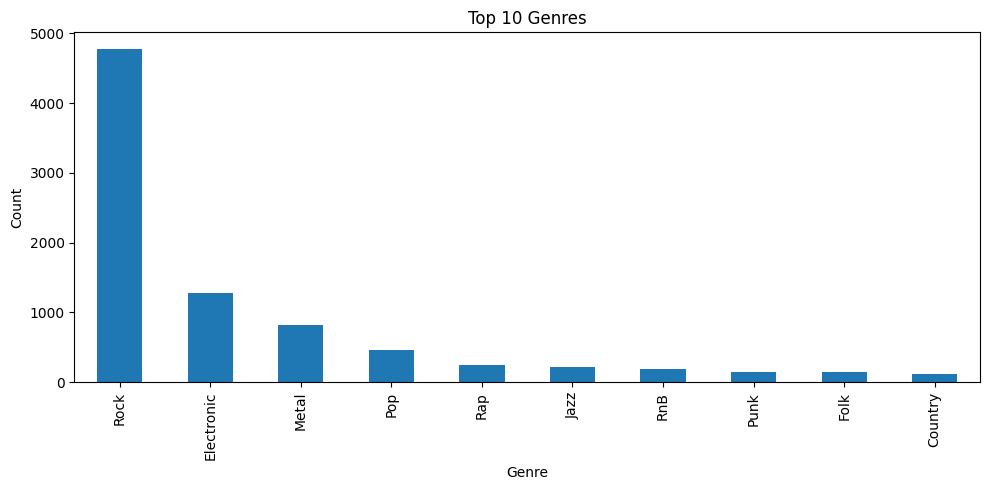

In [19]:
plt.figure(figsize=(10, 5))
df["genre"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

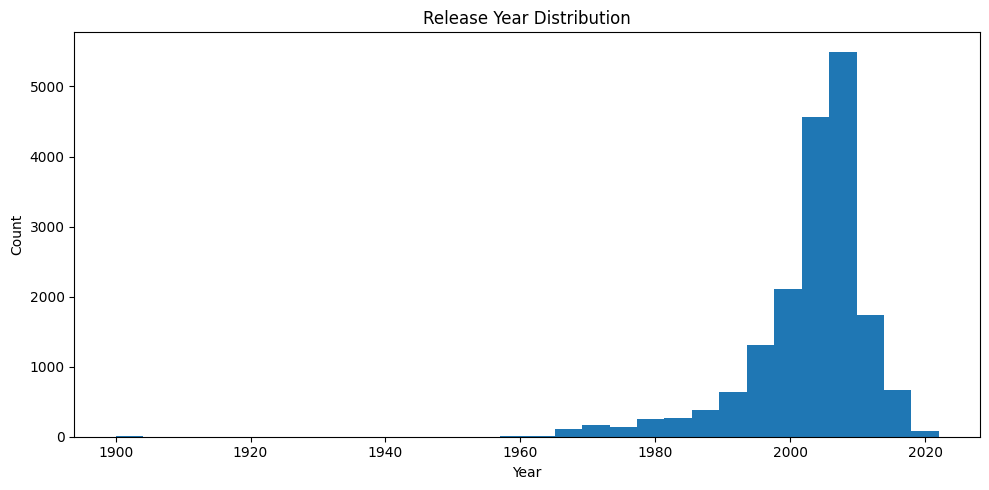

In [20]:
plt.figure(figsize=(10, 5))
df["year"].dropna().plot(kind="hist", bins=30)
plt.title("Release Year Distribution")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

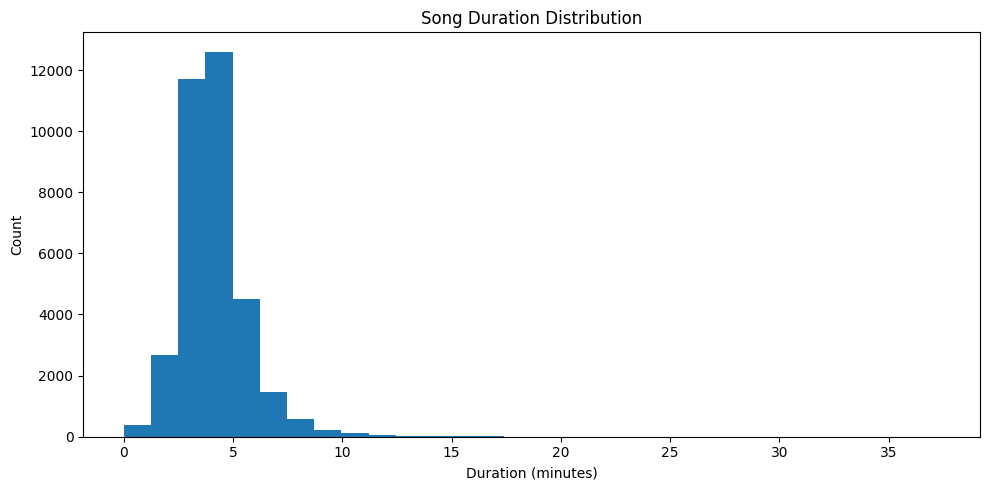

In [21]:
plt.figure(figsize=(10, 5))
df["duration_min"].dropna().plot(kind="hist", bins=30)
plt.title("Song Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()